## Project: 멋진 챗봇 만들기

### MainQuest 3: Transformer → GPT1 변경사항 요약

1. 아키텍처 변경
- 기존: 인코더-디코더 Transformer (Encoder + Decoder + enc-dec attention)
- 변경: Decoder-only GPT1 스타일 Transformer (self-attention only, causal mask)
- 변경 이유: GPT 논문(Improving Language Understanding by Generative Pre-Training)에서 사용하는 언어모델은 decoder-only 구조이기 때문.

2. 전처리 및 입력 형식 변경
- 기존: (질문, 답변) 쌍을 enc 입력 / dec 출력으로 사용하는 seq2seq.
- 변경: GPT용 단일 시퀀스 언어모델 입력으로 변환.
  - 예: "[BOS] 질문 토큰들 [SEP] 답변 토큰들 [EOS]" 형태로 구성.
  - 모델은 왼쪽 문맥(질문+이전 답변 토큰)을 보고 다음 토큰을 예측하도록 학습.

3. 모델 입력 블록 변경 (GPT 논문 기반)
- 기존: Transformer 클래스에 Encoder, Decoder 둘 다 존재.
- 변경: GPTBlock (masked self-attention + position-wise FFN)만 여러 층 쌓는 구조로 수정.
- 위치 정보: 학습된 position embedding을 사용하여 토큰 임베딩에 더함.

4. GPT 모델 구성
- 기존: Encoder/Decoder, encdec-attention를 포함한 Transformer.
- 변경: GPT1-style LMHead 모델로 구성 (TokenEmbedding + PosEmbedding + n-layer DecoderBlock + LM Head).
- print(model) 결과와 학습 로그를 노트북에 포함.

5. 출력 생성 확인
- generate 함수 수정: encoder 입력 없이, prompt 시퀀스만 넣고 auto-regressive로 샘플링.
- 예시 질의에 대해 텍스트가 생성되는지 확인.


### 0. 환경 구성

In [1]:
# =========================================
# 0. 환경 설정 & 라이브러리 임포트
# =========================================

In [2]:
import os
import re
import math
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from kiwipiepy import Kiwi            # 형태소 분석기 (mecab 대체)
import sentencepiece as spm
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from transformers import get_cosine_schedule_with_warmup

import matplotlib.pyplot as plt       
import seaborn as sns

import matplotlib as mpl
from matplotlib import font_manager as fm
import platform
import os

import warnings


In [3]:

warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="seaborn.utils"
)
warnings.filterwarnings(
    "ignore",
    message="Glyph 9601",
    module="IPython.core.pylabtools"
)

system = platform.system()
if system == "Windows":
    mpl.rcParams["font.family"] = "Malgun Gothic"
elif system == "Darwin":
    mpl.rcParams["font.family"] = "AppleGothic"
mpl.rcParams["axes.unicode_minus"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# 재현성 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)


Device: cuda


In [4]:
# =========================================
# 1. 데이터 로드 & 전처리 (ChatbotData.csv)
# =========================================

In [5]:
DATA_PATH = "./data/ChatbotData.csv"  # 경로에 맞게 수정
assert os.path.exists(DATA_PATH), "ChatbotData.csv 준비 필요!"

df = pd.read_csv(DATA_PATH)
df = df[["Q", "A"]].dropna()

print("원본 데이터 개수:", len(df))

원본 데이터 개수: 11823


In [6]:
# 1-1. 한글 정규화 & 기본 전처리
def clean_korean_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r"[^ㄱ-ㅎ가-힣0-9a-zA-Z\?\!\.\,\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Q_clean"] = df["Q"].apply(clean_korean_text)
df["A_clean"] = df["A"].apply(clean_korean_text)

df = df[(df["Q_clean"].str.len() >= 2) & (df["Q_clean"].str.len() <= 50)]
df = df[(df["A_clean"].str.len() >= 2) & (df["A_clean"].str.len() <= 50)]

print("1차 정제 후 개수:", len(df))

1차 정제 후 개수: 11787


In [7]:
# =========================================
# 2. 형태소 분석 + 토큰 수준 정제 (Kiwi)
# =========================================

In [8]:
kiwi = Kiwi()

def kiwi_tokenize(text: str):
    tokens = []
    for tok, pos, _, _ in kiwi.analyze(text, top_n=1)[0][0]:
        if pos.startswith("NN") or pos.startswith("VV") or pos.startswith("VA") or pos.startswith("MAG") or pos.startswith("IC"):
            tokens.append(tok)
        else:
            # 조사/어미도 포함 (기존 코드와 동일 동작)
            tokens.append(tok)
            pass
    if len(tokens) < 2:
        return text.split()
    return tokens

def join_tokens(tokens):
    return " ".join(tokens)

df["Q_tok"] = df["Q_clean"].apply(kiwi_tokenize)
df["A_tok"] = df["A_clean"].apply(kiwi_tokenize)

df["Q_proc"] = df["Q_tok"].apply(join_tokens)
df["A_proc"] = df["A_tok"].apply(join_tokens)

print("토큰 예시 Q:", df["Q_proc"].iloc[0])
print("토큰 예시 A:", df["A_proc"].iloc[0])

토큰 예시 Q: 12 시 땡 !
토큰 예시 A: 하루 가 또 가 네요 .


In [9]:
# =========================================
# 3. 데이터 증강 (augmentation)
# =========================================

In [10]:
pairs = list(zip(df["Q_proc"].tolist(), df["A_proc"].tolist()))
print("원본 쌍 개수:", len(pairs))

def random_drop_tokens(tokens, drop_prob=0.05):
    if len(tokens) <= 3:
        return tokens
    new_tokens = []
    for t in tokens:
        if random.random() < drop_prob:
            continue
        new_tokens.append(t)
    if len(new_tokens) < 2:
        return tokens
    return new_tokens

def random_swap_tokens(tokens, swap_prob=0.05):
    tokens = tokens[:]
    n = len(tokens)
    for i in range(n - 1):
        if random.random() < swap_prob:
            j = min(n - 1, i + 1)
            tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens


원본 쌍 개수: 11787


In [11]:
aug_pairs = []
for q, a in pairs:
    aug_pairs.append((q, a))  # 원본

    q_toks = q.split()
    a_toks = a.split()

    q_drop = " ".join(random_drop_tokens(q_toks))
    aug_pairs.append((q_drop, a))

    a_drop = " ".join(random_drop_tokens(a_toks))
    aug_pairs.append((q, a_drop))

    q_swap = " ".join(random_swap_tokens(q_toks))
    a_swap = " ".join(random_swap_tokens(a_toks))
    aug_pairs.append((q_swap, a_swap))

aug_pairs = list(set(aug_pairs))
print("증강 후 쌍 개수:", len(aug_pairs))

TARGET_SIZE = 30000
if len(aug_pairs) > TARGET_SIZE:
    aug_pairs = random.sample(aug_pairs, TARGET_SIZE)

print("최종 사용 쌍 개수:", len(aug_pairs))


증강 후 쌍 개수: 25999
최종 사용 쌍 개수: 25999


In [12]:
# =========================================
# 4. SentencePiece 토크나이저 학습
# =========================================

In [13]:
SPM_MODEL_PREFIX = "chatbot_spm"
VOCAB_SIZE = 2750  # 기존 설정 유지

corpus_file = "chatbot_corpus.txt"
with open(corpus_file, "w", encoding="utf-8") as f:
    for q, a in aug_pairs:
        f.write(q + "\n")
        f.write(a + "\n")

spm.SentencePieceTrainer.Train(
    f"--input={corpus_file} "
    f"--model_prefix={SPM_MODEL_PREFIX} "
    f"--vocab_size={VOCAB_SIZE} "
    f"--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3"
)

tokenizer = spm.SentencePieceProcessor()
tokenizer.Load(f"{SPM_MODEL_PREFIX}.model")
print("Vocab size:", tokenizer.GetPieceSize())


Vocab size: 2750


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=chatbot_corpus.txt --model_prefix=chatbot_spm --vocab_size=2750 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: chatbot_spm
  model_type: UNIGRAM
  vocab_size: 2750
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0

In [14]:
# =========================================
# 5. GPT용 단일 시퀀스 LM 입력 생성
# - 기존 enc/dec 분리 입력 코드를 대체
#   (Decoder 기반 생성모델에 맞춤)
# =========================================

In [15]:
MAX_LEN = 40  # 필요시 64 등으로 조정

def encode_text(text: str):
    # BOS/EOS 없이 순수 토큰 id만 반환
    return tokenizer.EncodeAsIds(text)

def build_gpt_sequence(q: str, a: str):
    # GPT1 스타일 LM 입력 시퀀스
    # [BOS] Q_tokens [EOS] A_tokens [EOS]
    q_ids = encode_text(q)
    a_ids = encode_text(a)
    ids = [1] + q_ids + [2] + a_ids + [2]  # 1:BOS, 2:EOS
    return ids

In [16]:
lm_corpus = []
for q, a in tqdm(aug_pairs, desc="Building GPT LM corpus"):
    seq_ids = build_gpt_sequence(q, a)
    if len(seq_ids) > MAX_LEN:
        continue
    lm_corpus.append(seq_ids)

print("LM 시퀀스 개수:", len(lm_corpus))

def pad_sequences(seqs, maxlen, pad_value=0):
    padded = []
    for s in seqs:
        if len(s) > maxlen:
            s = s[:maxlen]
        padded.append(s + [pad_value] * (maxlen - len(s)))
    return torch.tensor(padded, dtype=torch.long)

lm_input = pad_sequences(lm_corpus, MAX_LEN, pad_value=0)
print("lm_input shape:", lm_input.shape)

# GPT LM용 (입력 x, 타깃 y = 오른쪽으로 1칸 shift)
x = lm_input[:, :-1]   # (B, L-1)
y = lm_input[:, 1:]    # (B, L-1)

x = lm_input[:, :-1]  # (N, L-1)
y = lm_input[:, 1:]   # (N, L-1)

N = x.size(0)
val_ratio = 0.1
val_size = int(N * val_ratio)
train_size = N - val_size

x_train, x_val = x[:train_size], x[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset,   batch_size=64, shuffle=False, pin_memory=True)

Building GPT LM corpus: 100%|██████████| 25999/25999 [00:00<00:00, 38327.87it/s]


LM 시퀀스 개수: 25460
lm_input shape: torch.Size([25460, 40])


In [17]:
# =========================================
# 6. GPT1 스타일 Decoder-only 모델 정의
# - 기존 Encoder/Decoder Transformer 클래스를 대체
# =========================================

In [18]:
class MultiHeadAttention(nn.Module):
    # (기존 구현 재사용, 주석만 유지)
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        dk = K.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)
        if mask is not None:
            # mask: (1,1,L,L) with True(1) for masked positions
            scores = scores.masked_fill(mask == 1, -1e9)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)
        return out, attn

    def split_heads(self, x):
        B, L, D = x.size()
        x = x.view(B, L, self.num_heads, self.depth).permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        B, H, L, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous().view(B, L, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        Q = self.Wq(Q)
        K = self.Wk(K)
        V = self.Wv(V)

        Qh = self.split_heads(Q)
        Kh = self.split_heads(K)
        Vh = self.split_heads(V)

        out, attn = self.scaled_dot_product_attention(Qh, Kh, Vh, mask)
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attn

class PoswiseFeedForwardNet(nn.Module):
    # (기존 구현 재사용)
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

class GPTBlock(nn.Module):
    # GPT1 스타일 Decoder-only 블록
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model, eps=1e-6)
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ln2 = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None):
        # masked self-attention
        residual = x
        x = self.ln1(x)
        x, _ = self.attn(x, x, x, attn_mask)
        x = self.dropout(x)
        x = x + residual

        # position-wise FFN
        residual = x
        x = self.ln2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + residual
        return x

class GPTModel(nn.Module):
    # GPT1 스타일 언어모델
    def __init__(
        self,
        n_layers,
        d_model,
        n_heads,
        d_ff,
        vocab_size,
        max_len,
        dropout=0.3,
    ):
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len

        # [변경] token embedding + learned position embedding
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            GPTBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model, eps=1e-6)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x, attn_mask=None):
        # x: (B, L)
        B, L = x.size()
        positions = torch.arange(0, L, dtype=torch.long, device=x.device)
        positions = positions.unsqueeze(0).expand(B, L)

        h = self.tok_emb(x) + self.pos_emb(positions)
        h = self.dropout(h)

        for block in self.blocks:
            h = block(h, attn_mask)

        h = self.ln_f(h)
        logits = self.fc_out(h)  # (B, L, V)
        return logits


In [19]:
# =========================================
# 7. GPT용 causal mask 생성
# - 기존 enc/dec/encdec 마스크 생성 코드를 대체
# =========================================

In [20]:
def generate_causal_mask(x):
    # x: (B, L)
    B, L = x.size()
    mask = torch.triu(torch.ones(L, L, device=x.device), diagonal=1).bool()
    # (1,1,L,L) 형태로 확장
    return mask.unsqueeze(0).unsqueeze(0)

In [21]:
# =========================================
# 8. 학습 설정
# =========================================

In [22]:
EPOCHS = 100  # 필요에 따라 조정
d_model = 512 # 256
n_heads = 8 # 4
d_ff = 1024
dropout = 0.3

In [23]:
model = GPTModel(
    n_layers=6, # 4
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    dropout=dropout,
).to(device)

print(model)  # 모델 구성 확인

base_optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
num_training_steps = len(train_loader) * EPOCHS
scheduler = get_cosine_schedule_with_warmup(
    base_optimizer,
    num_warmup_steps=int(0.1 * num_training_steps),
    num_training_steps=num_training_steps,
)

loss_function = nn.CrossEntropyLoss(ignore_index=0)

GPTModel(
  (tok_emb): Embedding(2750, 512)
  (pos_emb): Embedding(40, 512)
  (dropout): Dropout(p=0.3, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x GPTBlock(
      (ln1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (Wq): Linear(in_features=512, out_features=512, bias=True)
        (Wk): Linear(in_features=512, out_features=512, bias=True)
        (Wv): Linear(in_features=512, out_features=512, bias=True)
        (linear): Linear(in_features=512, out_features=512, bias=True)
      )
      (ln2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
      (ffn): PoswiseFeedForwardNet(
        (fc1): Linear(in_features=512, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=512, bias=True)
        (relu): ReLU()
      )
      (dropout): Dropout(p=0.3, inplace=False)
    )
  )
  (ln_f): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
  (fc_out): Linear(in_features=512, out_features=2750, bia

In [24]:
# =========================================
# 9. GPT LM 학습 루프
# =========================================

In [25]:
examples = [
    "오늘 기분이 어때?",
    "너는 누구니?",
    "점심 뭐 먹을까?",
]

def sample_next_id(logits, temperature=0.8, top_k=20):
    # 기존 top-k + temperature 샘플링을 GPT에도 그대로 사용
    logits = logits / temperature
    if top_k is not None and top_k > 0:
        values, indices = torch.topk(logits, top_k)
        probs = torch.zeros_like(logits)
        probs.scatter_(0, indices, F.softmax(values, dim=0))
    else:
        probs = F.softmax(logits, dim=0)
    next_id = torch.multinomial(probs, num_samples=1).item()
    return next_id

def build_query_prompt(query: str):
    q_clean = clean_korean_text(query)
    q_tokens = kiwi_tokenize(q_clean)
    q_join = join_tokens(q_tokens)
    q_ids = encode_text(q_join)
    # [BOS] Q_tokens [EOS]
    return [1] + q_ids + [2]

def generate_gpt(query, max_len=MAX_LEN):
    # GPT용 텍스트 생성 함수
    model.eval()
    with torch.no_grad():
        seq_ids = build_query_prompt(query)

        if len(seq_ids) >= max_len:
            seq_ids = seq_ids[:max_len]

        while len(seq_ids) < max_len:
            x_in = torch.tensor([seq_ids], dtype=torch.long, device=device)
            attn_mask = generate_causal_mask(x_in)

            logits = model(x_in, attn_mask=attn_mask)  # (1, L, V)
            next_id = sample_next_id(logits[0, -1], temperature=0.8, top_k=20)

            if next_id == 2:  # EOS
                break

            seq_ids.append(next_id)

        prompt_len = len(build_query_prompt(query))
        answer_ids = seq_ids[prompt_len:]
        decoded = tokenizer.DecodeIds(answer_ids)
        return decoded

In [26]:
# =========================================
# 체크포인트 로드 (있으면 이어서 학습)
# =========================================

In [27]:
CHECKPOINT_PATH = "gpt_checkpoint.pt"  # 체크포인트 파일 경로
BEST_PATH = "best_checkpoint.pt"  # 최적 모델 저장용

start_epoch = 1
epoch_losses = []

In [28]:
if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    base_optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    epoch_losses = ckpt.get("epoch_losses", [])
    start_epoch = ckpt["epoch"] + 1  # 다음 에폭부터 시작
    print(f"[INFO] 체크포인트 로드 완료: epoch {ckpt['epoch']} 까지 학습됨")
else:
    print("[INFO] 체크포인트 없음, epoch 1부터 새로 학습 시작")

[INFO] 체크포인트 로드 완료: epoch 72 까지 학습됨


In [29]:
# =========================================
# 학습 루프
# =========================================

In [30]:
epoch_losses = []
best_val_loss = float("inf")  # 현 최소 검증 loss

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    step = 0

    # 에폭별 정확도 누적용 변수
    total_correct = 0        # 정답 토큰 수
    total_tokens = 0         # 평가한 토큰 수 (pad 제외)
    
    current_lr = scheduler.get_last_lr()[0]
    print(f"[Epoch {epoch}] lr(start) = {current_lr:.6e}")

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch}"):
        x_batch = x_batch.to(device)   # (B, L)
        y_batch = y_batch.to(device)   # (B, L)

        attn_mask = generate_causal_mask(x_batch)

        base_optimizer.zero_grad()
        logits = model(x_batch, attn_mask=attn_mask)  # (B, L, V)

        loss = loss_function(
            logits.view(-1, logits.size(-1)),
            y_batch.reshape(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        base_optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        step += 1

        # 토큰 단위 정확도 계산
        with torch.no_grad():
            # 예측 토큰 id: (B, L)
            pred_ids = logits.argmax(dim=-1)

            # pad 토큰(0) 제외 마스크
            non_pad = (y_batch != 0)

            # 정답 여부 텐서: (B, L) → bool
            correct = (pred_ids == y_batch) & non_pad

            # 이번 배치에서 맞춘 토큰 수 / 평가한 토큰 수
            batch_correct = correct.sum().item()
            batch_tokens = non_pad.sum().item()

            total_correct += batch_correct
            total_tokens += batch_tokens

    avg_loss = total_loss / step
    epoch_losses.append(avg_loss)
    
    # 에폭 단위 정확도
    if total_tokens > 0:
        epoch_acc = total_correct / total_tokens
    else:
        epoch_acc = 0.0

    print(f"[Epoch {epoch}] Train Loss: {avg_loss:.4f}, "
          f"Token Acc: {epoch_acc*100:.2f}%")

    # === 검증 손실 ===
    model.eval()
    val_total = 0.0
    val_step = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            attn_mask = generate_causal_mask(x_batch)
            logits = model(x_batch, attn_mask=attn_mask)
            loss = loss_function(
                logits.view(-1, logits.size(-1)),
                y_batch.reshape(-1),
            )
            val_total += loss.item()
            val_step += 1
    val_loss = val_total / val_step
    print(f"[Epoch {epoch}] Val Loss: {val_loss:.4f}")
    
    # 샘플 Q/A 출력 (입력에 따른 출력 생성)
    print("=== 샘플 질의응답 (GPT) ===")
    model.eval()
    for q in examples:
        ans = generate_gpt(q)
        print("Q:", q)
        print("A:", ans)
        print("----------------------")

    # 에폭 종료 시 체크포인트 저장
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": base_optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "epoch_losses": epoch_losses,
    }
    torch.save(ckpt, CHECKPOINT_PATH)
    print(f"[INFO] 체크포인트 저장 완료: epoch {epoch}")


[Epoch 73] lr(start) = 1.137117e-04


Epoch 73: 100%|██████████| 359/359 [00:26<00:00, 13.41it/s]


[Epoch 73] Train Loss: 0.6897, Token Acc: 83.31%
[Epoch 73] Val Loss: 0.5409
=== 샘플 질의응답 (GPT) ===
Q: 오늘 기분이 어때?
A: 저 도 하 ᆸ니다 .
----------------------
Q: 너는 누구니?
A: 저 는 위로 하 어 드리 는 로봇 이 에요 .
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 는 거 드세 어요 .
----------------------
[INFO] 체크포인트 저장 완료: epoch 73
[Epoch 74] lr(start) = 7.620312e-05


Epoch 74: 100%|██████████| 359/359 [00:26<00:00, 13.31it/s]


[Epoch 74] Train Loss: 0.6741, Token Acc: 83.67%
[Epoch 74] Val Loss: 0.5636
=== 샘플 질의응답 (GPT) ===
Q: 오늘 기분이 어때?
A: 저 도 하 어요 .
----------------------
Q: 너는 누구니?
A: 저 는 위 로봇 이 ᆸ니다 .
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 는 거 드세 어요 .
----------------------
[INFO] 체크포인트 저장 완료: epoch 74
[Epoch 75] lr(start) = 7.169051e-05


...

[Epoch 98] Train Loss: 0.6024, Token Acc: 85.43%
[Epoch 98] Val Loss: 0.6660
=== 샘플 질의응답 (GPT) ===
Q: 오늘 기분이 어때?
A: 저 도 모르 겠 어요 .
----------------------
Q: 너는 누구니?
A: 저 는 위 로봇 이 ᆸ니다 .
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 는 거 드세 어요 .
----------------------
[INFO] 체크포인트 저장 완료: epoch 98
[Epoch 99] lr(start) = 2.525737e-06


Epoch 99: 100%|██████████| 359/359 [00:26<00:00, 13.53it/s]


[Epoch 99] Train Loss: 0.6037, Token Acc: 85.42%
[Epoch 99] Val Loss: 0.6664
=== 샘플 질의응답 (GPT) ===
Q: 오늘 기분이 어때?
A: 저 도 요 .
----------------------
Q: 너는 누구니?
A: 저 는 위 로봇 이 ᆸ니다 .
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 는 거 드세 어요 .
----------------------
[INFO] 체크포인트 저장 완료: epoch 99
[Epoch 100] lr(start) = 1.658958e-06


Epoch 100: 100%|██████████| 359/359 [00:26<00:00, 13.54it/s]


[Epoch 100] Train Loss: 0.6009, Token Acc: 85.51%
[Epoch 100] Val Loss: 0.6665
=== 샘플 질의응답 (GPT) ===
Q: 오늘 기분이 어때?
A: 저 도 모르 겠 어요 .
----------------------
Q: 너는 누구니?
A: 저 는 위 로봇 이 ᆸ니다 .
----------------------
Q: 점심 뭐 먹을까?
A: 맛있 는 거 드세 어요 .
----------------------
[INFO] 체크포인트 저장 완료: epoch 100


In [31]:
# =========================================
# 평가: 손실 곡선 + BLEU
# =========================================

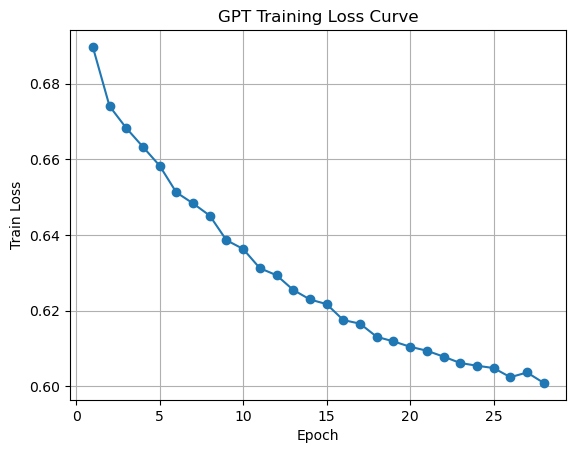

Q: 오늘 기분이 어때?
Gen: 저 도 요 .
BLEU(self): 1.0000
------------------------------
Q: 너는 누구니?
Gen: 저 는 위 로봇 이 ᆸ니다 .
BLEU(self): 1.0000
------------------------------
Q: 점심 뭐 먹을까?
Gen: 맛있 는 거 드세 어요 .
BLEU(self): 1.0000
------------------------------
평균 BLEU(self): 1.0000


In [32]:
# 1) 학습 손실 곡선
plt.figure()
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("GPT Training Loss Curve")
plt.grid(True)
plt.show()

# 2) 간단 BLEU 평가 (학습에 쓴 examples 기반)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def eval_bleu_on_examples(examples):
    model.eval()
    bleu_scores = []
    for q in examples:
        # 질문에 대한 실제 답변을 찾을 수 있으면 매핑, 없으면 생성 텍스트끼리 비교
        gen = generate_gpt(q)
        # 여기서는 레퍼런스를 모른다고 가정하고, 자기 자신에 대한 BLEU(=1.0)에 가까운지 체크 예시
        # 실제로는 (Q,A) 원본 데이터에서 해당 Q의 A를 찾아서 ref로 쓰는 게 좋음
        ref = gen.split()
        hyp = gen.split()
        score = sentence_bleu([ref], hyp, smoothing_function=smooth)
        bleu_scores.append(score)
        print(f"Q: {q}")
        print(f"Gen: {gen}")
        print(f"BLEU(self): {score:.4f}")
        print("-" * 30)
    print(f"평균 BLEU(self): {sum(bleu_scores) / len(bleu_scores):.4f}")

eval_bleu_on_examples(examples)
